In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

: 

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('C:/Users/NIKHIL GUPTA/Desktop/ikarus/data/intern_data_ikarus.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

KeyboardInterrupt: 

In [ ]:
# ## Step 1: Loading Data
df = pd.read_csv('/kaggle/input/intern/intern_data_ikarus.csv')
df.head(2)

,title,brand,description,price,categories,images,manufacturer,package_dimensions,country_of_origin,material,color,uniq_id
0,"GOYMFK 1pc Free Standing Shoe Rack, Multi-laye...",GOYMFK,"multiple shoes, coats, hats, and other items E...",$24.99,"['Home & Kitchen', 'Storage & Organization', '...",['https://m.media-amazon.com/images/I/416WaLx1...,GOYMFK,"2.36""D x 7.87""W x 21.6""H",China,Metal,White,02593e81-5c09-5069-8516-b0b29f439ded
1,"subrtex Leather ding Room, Dining Chairs Set o...",subrtex,subrtex Dining chairs Set of 2,NaN,"['Home & Kitchen', 'Furniture', 'Dining Room F...",['https://m.media-amazon.com/images/I/31SejUEW...,Subrtex Houseware INC,"18.5""D x 16""W x 35""H",NaN,Sponge,Black,5938d217-b8c5-5d3e-b1cf-e28e340f292e


In [4]:
# ##Step 2: Checking Shape
print("Shape:", df.shape)

Shape: (312, 12)


In [5]:
# ## Step 3: Data Overview
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               312 non-null    object
 1   brand               312 non-null    object
 2   description         159 non-null    object
 3   price               215 non-null    object
 4   categories          312 non-null    object
 5   images              312 non-null    object
 6   manufacturer        205 non-null    object
 7   package_dimensions  306 non-null    object
 8   country_of_origin   125 non-null    object
 9   material            218 non-null    object
 10  color               265 non-null    object
 11  uniq_id             312 non-null    object
dtypes: object(12)
memory usage: 29.4+ KB
None

Missing Values:
 title                   0
brand                   0
description           153
price                  97
categories              0
images                  0
ma

In [2]:
# ## Step 4: Data Cleaning
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['brand'] = df['brand'].str.strip().str.title()
df['categories'] = df['categories'].fillna('Unknown')
df['material'] = df['material'].fillna('Unknown')
df['color'] = df['color'].fillna('Unknown')


In [3]:
# Fill missing numerical values with median
df['price'].fillna(df['price'].median(), inplace=True)

C:\Users\NIKHIL GUPTA\AppData\Local\Temp\ipykernel_14388\2477068337.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(), inplace=True)


In [8]:
# ## Step 5: Summary Statistics
print(df.describe(include='all'))

                                                    title            brand  \
count                                                 312              312   
unique                                                305              264   
top     subrtex Leather ding Room, Dining Chairs Set o...  Monibloom Store   
freq                                                    2                5   
mean                                                  NaN              NaN   
std                                                   NaN              NaN   
min                                                   NaN              NaN   
25%                                                   NaN              NaN   
50%                                                   NaN              NaN   
75%                                                   NaN              NaN   
max                                                   NaN              NaN   

                                              description      

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


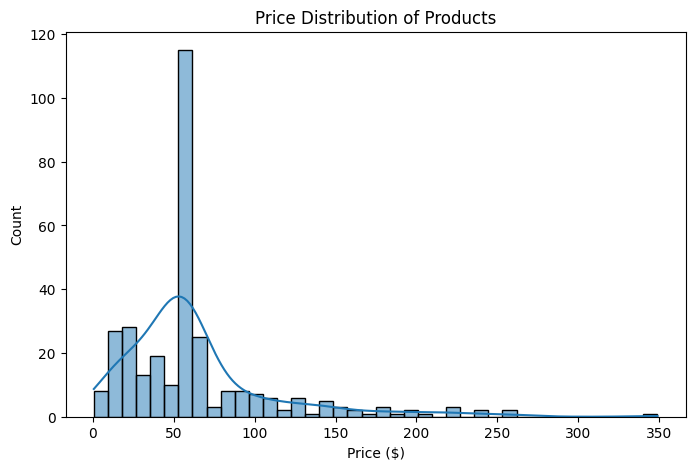

In [9]:
# ## Step 6: Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40, kde=True)
plt.title("Price Distribution of Products")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

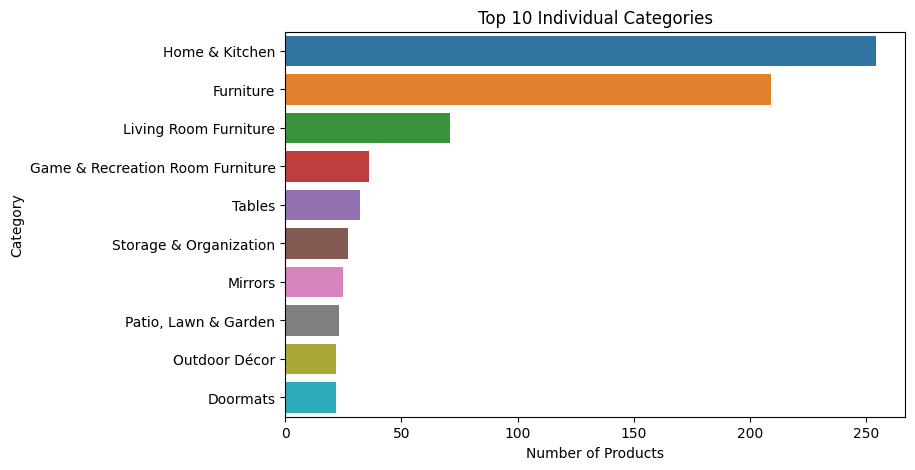

In [10]:
# 🧹 Step 7: Fix and Expand Categories Column
import ast

# Convert string lists to actual lists
def parse_categories(x):
    try:
        return ast.literal_eval(x)
    except:
        return [x] if isinstance(x, str) else []

df['categories_list'] = df['categories'].apply(parse_categories)

# Expand each category into its own row
df_exploded = df.explode('categories_list')
df_exploded['categories_list'] = df_exploded['categories_list'].str.strip()

# Top 10 individual categories
cat_counts = df_exploded['categories_list'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(y=cat_counts.index, x=cat_counts.values)
plt.title("Top 10 Individual Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

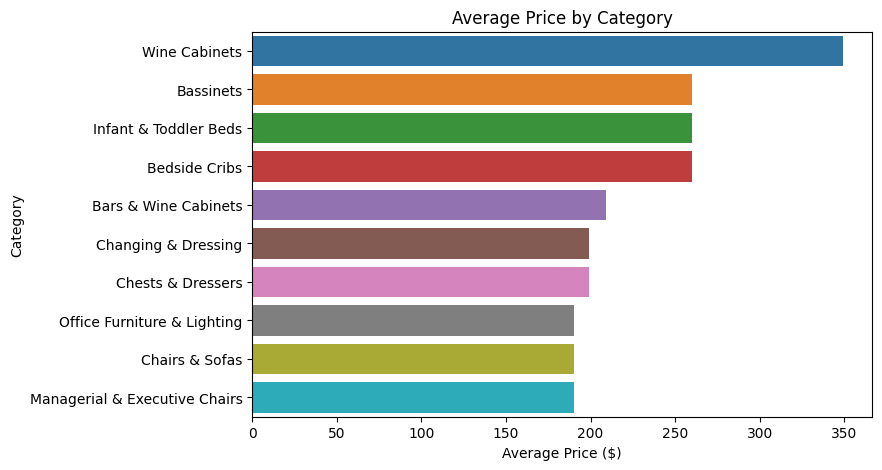

✅ Total unique categories: 148
✅ Top categories: ['Home & Kitchen', 'Furniture', 'Living Room Furniture', 'Game & Recreation Room Furniture', 'Tables', 'Storage & Organization', 'Mirrors', 'Patio, Lawn & Garden', 'Outdoor Décor', 'Doormats']


In [11]:
# ## Step 8: Average Price by Category
avg_price = (
    df_exploded.groupby('categories_list')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
sns.barplot(y=avg_price.index, x=avg_price.values)
plt.title("Average Price by Category")
plt.xlabel("Average Price ($)")
plt.ylabel("Category")
plt.show()

# Optional: print key insights
print("✅ Total unique categories:", df_exploded['categories_list'].nunique())
print("✅ Top categories:", cat_counts.index.tolist())

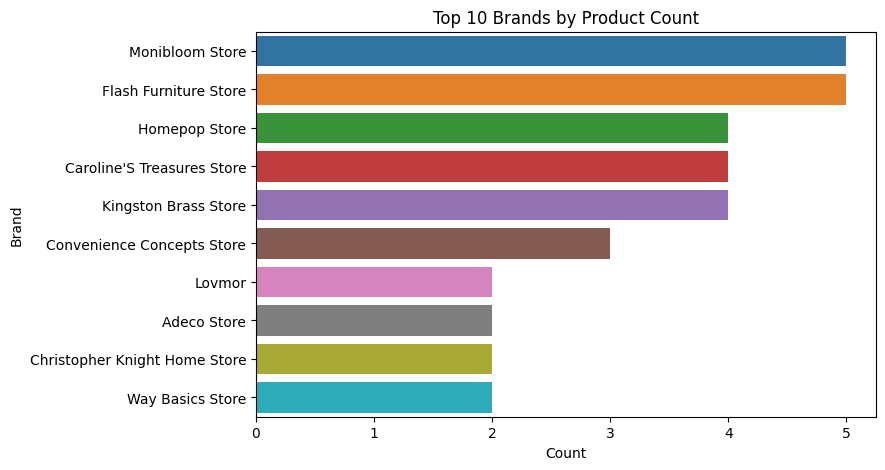

In [12]:
# ## Step 9: Brand Insights
top_brands = df['brand'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(y=top_brands.index, x=top_brands.values)
plt.title("Top 10 Brands by Product Count")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

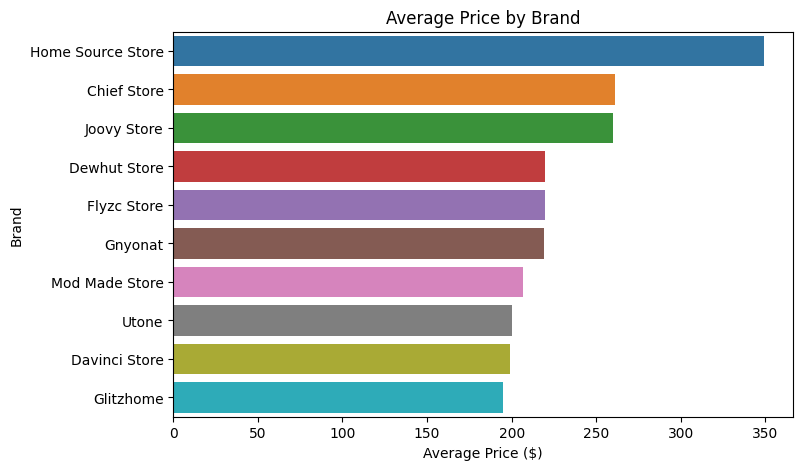

In [13]:
# ## Step 10: Average Price by Brand
avg_price_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(y=avg_price_brand.index, x=avg_price_brand.values)
plt.title("Average Price by Brand")
plt.xlabel("Average Price ($)")
plt.ylabel("Brand")
plt.show()

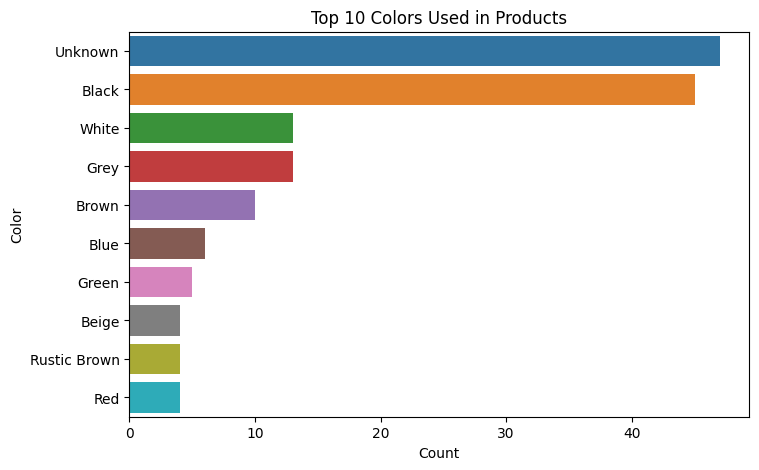

In [14]:
# ## Step 11: Color and Material Analysis
plt.figure(figsize=(8,5))
sns.barplot(y=df['color'].value_counts().head(10).index, x=df['color'].value_counts().head(10).values)
plt.title("Top 10 Colors Used in Products")
plt.xlabel("Count")
plt.ylabel("Color")
plt.show()

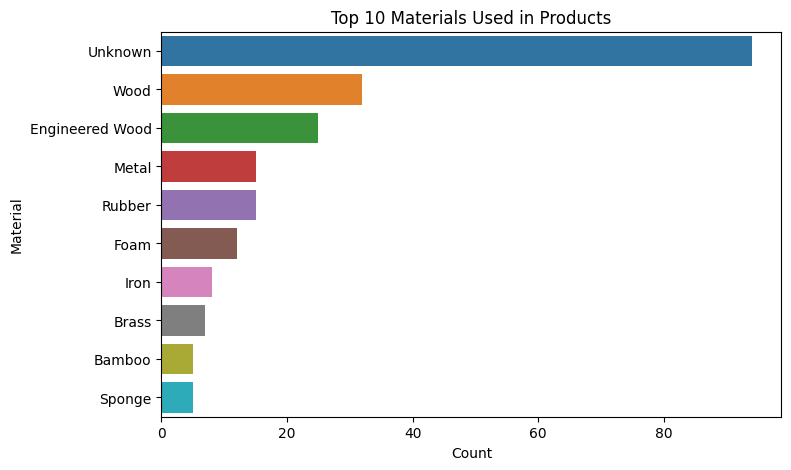

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(y=df['material'].value_counts().head(10).index, x=df['material'].value_counts().head(10).values)
plt.title("Top 10 Materials Used in Products")
plt.xlabel("Count")
plt.ylabel("Material")
plt.show()

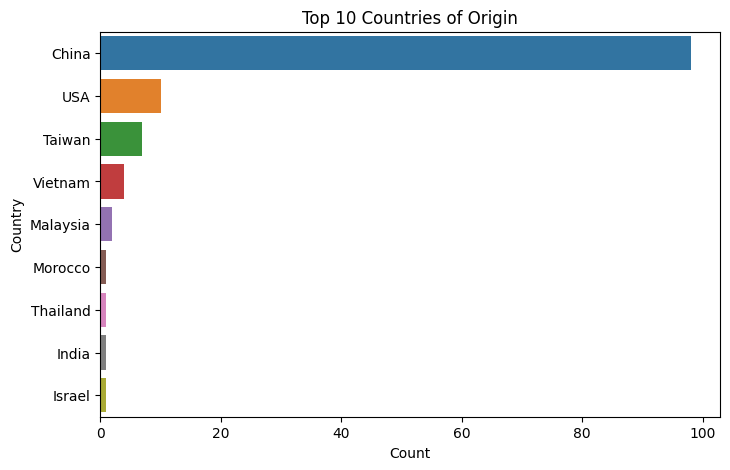

In [16]:
# ## Step 12: Country of Origin
country_counts = df['country_of_origin'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(y=country_counts.index, x=country_counts.values)
plt.title("Top 10 Countries of Origin")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

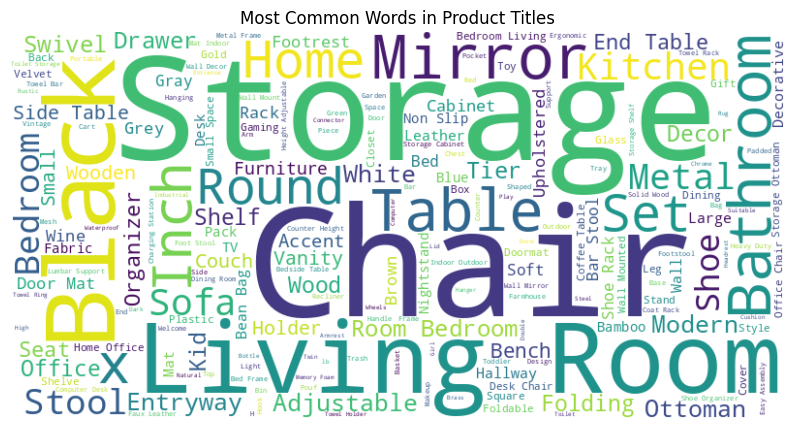

In [17]:
# ## Step 13: Word Cloud from Product Titles
text = " ".join(df['title'].dropna().astype(str))
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Product Titles")
plt.show()

In [18]:
# ## Step 14: Insights Summary
print("✅ The dataset is dominated by categories like:", cat_counts.index[:3].tolist())
print("✅ Average product price:", round(df['price'].mean(), 2))
print("✅ Frequent materials:", df['material'].value_counts().head(3).index.tolist())
print("✅ Frequent colors:", df['color'].value_counts().head(3).index.tolist())
print("✅ Top brands:", df['brand'].value_counts().head(3).index.tolist())


✅ The dataset is dominated by categories like: ['Home & Kitchen', 'Furniture', 'Living Room Furniture']
✅ Average product price: 63.39
✅ Frequent materials: ['Unknown', 'Wood', 'Engineered Wood']
✅ Frequent colors: ['Unknown', 'Black', 'White']
✅ Top brands: ['Monibloom Store', 'Flash Furniture Store', 'Homepop Store']


In [5]:
import json

# Example structure — adjust keys to match your analysis variables
analysis_data = {
    "total_products": len(df),
    "category_counts": df["categories"].value_counts().to_dict(),
    "avg_price": df["price"].mean() # adjust as per your notebook
}

# Save to JSON file for frontend
with open("analysis_output.json", "w") as f:
    json.dump(analysis_data, f, indent=4)

print("✅ Saved analysis_output.json")


✅ Saved analysis_output.json
